In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías y de `listings_train.csv`/`listings_test.csv`, el split guardado por `03_model_baseline.ipynb` (mismo `random_state=42`, para que los resultados sean comparables entre notebooks).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
train_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/valencia/listings_train.csv")
test_df = pd.read_csv(f"{PROJECT_DIR}/data/processed/valencia/listings_test.csv")
train_df.shape, test_df.shape

((5787, 88), (1447, 88))

## 2. ¿Qué modelos vamos a probar?

En el baseline, la regresión lineal se quedó bastante corta (R²=0.32) y confirmó que `price` no depende de forma lineal de las variables en Valencia. Con eso en mente, se prueban los mismos cuatro tipos de modelo que en Barcelona/Madrid:

- **Ridge**: versión regularizada de la regresión lineal del baseline. Sirve para ver cuánto más se le puede sacar a un modelo lineal antes de pasar a algo no lineal.
- **Random Forest**: ensemble por *bagging* de árboles de decisión. Robusto, apenas necesita ajuste, no le afecta la escala ni la multicolinealidad. No admite `NaN`.
- **Extra Trees**: variante de Random Forest con aleatoriedad extra al elegir los cortes de cada árbol. Tampoco admite `NaN`.
- **Hist Gradient Boosting**: ensemble por *boosting* basado en histogramas, el sustituto de `scikit-learn` más parecido a XGBoost/LightGBM (que no se pudieron usar por el problema de `libomp`, igual que en Barcelona/Madrid). Admite `NaN` nativamente.

Los cuatro se entrenan dentro de un `Pipeline`. Para Ridge/Random Forest/Extra Trees el pipeline incluye un paso de imputación (y de escalado, solo para Ridge); para Hist Gradient Boosting no se imputa nada, para conservar la información de "sin reviews todavía" que aporta el propio `NaN`.

## 3. Preparación de X e y

Mismos identificadores, objetivo y columnas de fuga que en `03_model_baseline.ipynb`. A diferencia del baseline, aquí no se imputa nada todavía: eso queda dentro de cada `Pipeline`.

### 3.1 Identificadores, objetivo y columnas de fuga

In [3]:
id_cols = ["id", "host_id", "host_profile_id"]
target_col = "price"
leakage_cols = ["price_log", "price_per_accommodate", "price_per_min_night"]
feature_cols = [c for c in train_df.columns if c not in id_cols + [target_col] + leakage_cols]

len(feature_cols)

81

### 3.2 X e y

`train_df`/`test_df` ya son el split guardado por el baseline, así que aquí no hace falta volver a dividir nada.

In [4]:
X_train, y_train = train_df[feature_cols].copy(), train_df[target_col].copy()
X_test, y_test = test_df[feature_cols].copy(), test_df[target_col].copy()

X_train.shape, X_test.shape

((5787, 81), (1447, 81))

### 3.3 Booleanas a 0/1

In [5]:
bool_cols = X_train.select_dtypes(include="bool").columns
X_train[bool_cols] = X_train[bool_cols].astype(int)
X_test[bool_cols] = X_test[bool_cols].astype(int)

len(bool_cols)

50

### 3.4 Nulos: sin tratar todavía

`review_scores_rating`, `listing_age_days` y `days_since_last_review` se quedan con sus `NaN` tal cual; cada `Pipeline` de la sección 4 decide si los imputa o los deja pasar al modelo.

In [6]:
X_train.isnull().sum()[X_train.isnull().sum() > 0]

review_scores_rating      616
listing_age_days          616
days_since_last_review    616
dtype: int64

## 4. Pipelines

Un `Pipeline` por modelo, con el preprocesado que necesita cada uno.

### 4.1 Objetivo: `log1p(price)`

Mismo criterio que en el baseline: se entrena sobre `log1p(price)`, no sobre `price` directamente.

In [7]:
y_train_log = np.log1p(y_train)

### 4.2 Un `Pipeline` por modelo

In [8]:
pipelines = {
    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(random_state=42)),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Extra Trees": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1)),
    ]),
    "Hist Gradient Boosting": Pipeline([
        ("model", HistGradientBoostingRegressor(random_state=42)),
    ]),
}

list(pipelines.keys())

['Ridge', 'Random Forest', 'Extra Trees', 'Hist Gradient Boosting']

Con hiperparámetros por defecto en los cuatro por ahora: el ajuste fino es la sección 6.

## 5. Entrenamiento y comparación entre modelos

Los cuatro pipelines evaluados por validación cruzada sobre el train (sin tocar el test todavía).

### 5.1 Función `evaluate` y validación cruzada manual

In [9]:
def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"modelo": name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

### 5.2 Comparar los cuatro con 5-fold CV

In [10]:
from sklearn.model_selection import KFold

def cv_evaluate(pipeline, X, y_log, name, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]
        pipeline.fit(X_tr, y_tr_log)
        pred = np.expm1(pipeline.predict(X_val))
        y_val = np.expm1(y_val_log)
        scores.append(evaluate(y_val, pred, name))
    return pd.DataFrame(scores).drop(columns="modelo").mean()

cv_rows = []
for name, pipe in pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    cv_rows.append(scores)

cv_results = pd.DataFrame(cv_rows).set_index("modelo")
cv_results.round(2)

/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/yagocoll/Documents/Master/Airbnb/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.p

,RMSE,MAE,R2,MAPE
modelo,,,,
Ridge,147.36,47.13,0.25,28.90
Random Forest,145.22,43.04,0.28,24.62
Extra Trees,145.30,42.71,0.28,24.08
Hist Gradient Boosting,143.96,42.71,0.29,24.61


### 5.3 Interpretación

**Diferencia notable con Barcelona**: allí Ridge (R²=0.68) quedaba muy por detrás de los tres modelos de árboles (0.75-0.77). Aquí los cuatro están mucho más apretados: Ridge (R²=0.25), Random Forest (0.28), Extra Trees (0.28) y Hist Gradient Boosting (0.29, el mejor de los cuatro con hiperparámetros por defecto). El salto de "lineal" a "no lineal" es mucho más pequeño en Valencia. Encaja con lo ya visto en `03_model_baseline.ipynb`: la relación entre las variables y `price` es más ruidosa aquí en general, no solo menos lineal, así que ni siquiera un modelo de árboles sin afinar saca una ventaja tan clara todavía.

Como en Barcelona, esta comparación no decide nada: los tres modelos de árboles se afinan igualmente en la sección 6, no solo el que gane aquí por poco.

## 6. Ajuste de hiperparámetros

Se afinan Random Forest, Extra Trees y Hist Gradient Boosting con `RandomizedSearchCV` y validación cruzada.

`RandomizedSearchCV` con 15 combinaciones y 3 folds por modelo (45 entrenamientos cada uno), sobre `y_train_log` con `scoring="r2"`.

### 6.1 Random Forest

In [11]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
rf_search.fit(X_train, y_train_log)

print(rf_search.best_params_)
print(rf_search.best_score_)

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 30}
0.7310852501263452


### 6.2 Extra Trees

In [12]:
et_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2", 0.5],
}

et_search = RandomizedSearchCV(
    pipelines["Extra Trees"], et_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
et_search.fit(X_train, y_train_log)

print(et_search.best_params_)
print(et_search.best_score_)

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_features': 0.5, 'model__max_depth': 30}
0.7331450221758756


### 6.3 Hist Gradient Boosting

In [13]:
hgb_param_dist = {
    "model__max_iter": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_leaf_nodes": [15, 31, 63, 127],
    "model__l2_regularization": [0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    pipelines["Hist Gradient Boosting"], hgb_param_dist,
    n_iter=15, cv=3, scoring="r2", random_state=42, n_jobs=-1,
)
hgb_search.fit(X_train, y_train_log)

print(hgb_search.best_params_)
print(hgb_search.best_score_)

{'model__max_leaf_nodes': 31, 'model__max_iter': 200, 'model__max_depth': 15, 'model__learning_rate': 0.05, 'model__l2_regularization': 0.1}
0.7368974769837218


### 6.4 Resumen

Los tres suben de R²≈0.28-0.29 (sin afinar, en euros) a **R²≈0.73-0.74 en escala logarítmica** con los mejores hiperparámetros. Ojo: este número está en la escala de `log1p(price)`, no es directamente comparable con la tabla en euros de la sección 5 — la comparación justa en euros se hace en la sección 7.

## 7. Elegir el modelo final

Los tres modelos ya afinados, comparados entre sí (seguimos sin tocar el test).

### 7.1 Comparar en euros con los mejores hiperparámetros

In [14]:
from sklearn.base import clone

tuned_pipelines = {
    "Random Forest (tuned)": clone(rf_search.best_estimator_),
    "Extra Trees (tuned)": clone(et_search.best_estimator_),
    "Hist Gradient Boosting (tuned)": clone(hgb_search.best_estimator_),
}

tuned_rows = []
for name, pipe in tuned_pipelines.items():
    scores = cv_evaluate(pipe, X_train, y_train_log, name)
    scores["modelo"] = name
    tuned_rows.append(scores)

tuned_results = pd.DataFrame(tuned_rows).set_index("modelo")
tuned_results.round(2)

,RMSE,MAE,R2,MAPE
modelo,,,,
Random Forest (tuned),144.81,42.44,0.29,24.30
Extra Trees (tuned),144.95,42.03,0.28,23.55
Hist Gradient Boosting (tuned),143.76,42.28,0.30,24.35


### 7.2 Decisión

Aquí el resultado está más repartido que en Barcelona: **Hist Gradient Boosting gana en RMSE (143.76) y R² (0.297)**, pero **Extra Trees gana en MAE (42.05) y MAPE (23.61)** por un margen pequeño en los cuatro casos. Un empate técnico 2-2, no la victoria clara de Barcelona (3 de 4 métricas).

Se decide igualmente por **Hist Gradient Boosting**, por tres motivos que pesan más que el margen ajustado en MAE/MAPE: (1) gana en RMSE y R², las dos métricas más sensibles a los errores grandes, que es justo donde más cuesta acertar dado lo larga que es la cola de `price` en Valencia; (2) no necesita imputar `review_scores_rating`/`listing_age_days`/`days_since_last_review`, así que aprovecha la señal de "sin reviews todavía" sin perder información; (3) mantiene la comparación metodológica con Barcelona/Madrid, donde también ganó.

In [15]:
final_model_name = "Hist Gradient Boosting"
final_pipeline = hgb_search.best_estimator_
final_pipeline

Pipeline(steps=[('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               learning_rate=0.05, max_depth=15,
                                               max_iter=200,
                                               random_state=42))])

## 8. Evaluación en test

El modelo elegido en la sección 7, entrenado sobre todo el train y evaluado una única vez sobre el test.

### 8.1 Evaluar en test, por primera y única vez

In [16]:
pred_final = np.expm1(final_pipeline.predict(X_test))

evaluate(y_test, pred_final, "Hist Gradient Boosting (final)")

{'modelo': 'Hist Gradient Boosting (final)',
 'RMSE': np.float64(110.42846365835543),
 'MAE': 39.64633545127884,
 'R2': 0.37294957844113097,
 'MAPE': np.float64(24.096367659813854)}

### 8.2 Train vs. test: ¿hay sobreajuste?

In [17]:
pred_train = np.expm1(final_pipeline.predict(X_train))

pd.DataFrame([
    evaluate(y_train, pred_train, "Train"),
    evaluate(y_test, pred_final, "Test"),
]).set_index("modelo")

,RMSE,MAE,R2,MAPE
modelo,,,,
Train,146.037829,31.432296,0.333001,16.565117
Test,110.428464,39.646335,0.372950,24.096368


**Resultado inusual, y no es un error**: el MAE se comporta como se esperaría (31.4€ en train frente a 39.6€ en test, el modelo acierta más de cerca en los datos con los que entrenó), pero el R² es **más alto en test (0.373) que en train (0.333)**, y el RMSE más bajo en test (110.4€) que en train (146.0€) — justo al revés que en Barcelona.

La causa está en la propia cola de `price`, no en el modelo: el split de `03_model_baseline.ipynb` repartió los precios extremos de forma desigual por puro azar. `y_train` tiene una asimetría de 28.6 (con el máximo de todo el dataset, 9593€) y `y_test` de solo 10.7 (máximo 3511€) — train se quedó con la cola más larga. Como RMSE y R² penalizan los errores grandes al cuadrado, un puñado de precios extremos en train basta para hundir esas dos métricas allí, aunque el modelo generalice bien al resto de los datos (el MAE, mucho menos sensible a esos extremos, sí muestra el patrón normal). No es sobreajuste: es varianza de un único split aleatorio frente a una variable con una cola extremadamente larga, y es precisamente el tipo de matiz que conviene tener en cuenta en `05_model_evaluation.ipynb` antes de sacar conclusiones de una sola partición train/test.

## 9. Comparación con el baseline

El resultado de la sección 8 frente al listón de `03_model_baseline.ipynb` (regresión lineal: R²=0.32, MAE≈45.5€).

In [18]:
{
    "Regresión lineal (baseline)": {"RMSE": 114.70, "MAE": 45.55, "R2": 0.32, "MAPE": 29.10},
    "Hist Gradient Boosting (final)": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
}

{'Regresión lineal (baseline)': {'RMSE': 114.7,
  'MAE': 45.55,
  'R2': 0.32,
  'MAPE': 29.1},
 'Hist Gradient Boosting (final)': {'modelo': 'Hist Gradient Boosting (final)',
  'RMSE': np.float64(110.42846365835543),
  'MAE': 39.64633545127884,
  'R2': 0.37294957844113097,
  'MAPE': np.float64(24.096367659813854)}}

Mejora en las cuatro métricas, pero de una magnitud mucho más modesta que en Barcelona (allí el salto era RMSE 172→141€, aquí 114.7→110.4€): **RMSE de 114.7€ a 110.4€, MAE de 45.5€ a 39.6€, R² de 0.32 a 0.37, MAPE de 29.1% a 24.1%**. Un modelo de árboles bien afinado sigue aportando una mejora real y consistente sobre un modelo lineal, pero el techo alcanzable en Valencia con estas variables parece bastante más bajo que en Barcelona/Madrid — coherente con toda la cadena de hallazgos desde la EDA (cola de `price` mucho más larga, correlaciones de tamaño más débiles, `distance_to_center_km` sin señal por el patrón de doble polo).

## 10. Importancia de variables

Igual que en Barcelona: `HistGradientBoostingRegressor` no tiene `feature_importances_`, así que se usa **permutation importance**.

### 10.1 Calcular la importancia

Se calcula sobre el test, para medir qué variables son importantes de cara a generalizar.

In [19]:
from sklearn.inspection import permutation_importance

y_test_log = np.log1p(y_test)

perm_result = permutation_importance(
    final_pipeline, X_test, y_test_log,
    scoring="r2", n_repeats=10, random_state=42, n_jobs=-1,
)

importances = pd.Series(perm_result.importances_mean, index=X_test.columns).sort_values(ascending=False)
importances.head(15)

minimum_nights                    0.287430
accommodates                      0.164454
room_type_Entire home/apt         0.127288
host_entire_homes_ratio           0.030403
neighbourhood_price_encoded       0.024844
bathrooms                         0.022106
availability_365                  0.017292
review_scores_rating              0.012906
has_ac                            0.010074
n_amenities                       0.009965
calculated_host_listings_count    0.008335
beds                              0.007063
host_tenure_years                 0.006945
host_user_tenure_years            0.005617
estimated_occupancy_l365d         0.005352
dtype: float64

Text(0.5, 0, 'Caída de R² al desordenar la variable')

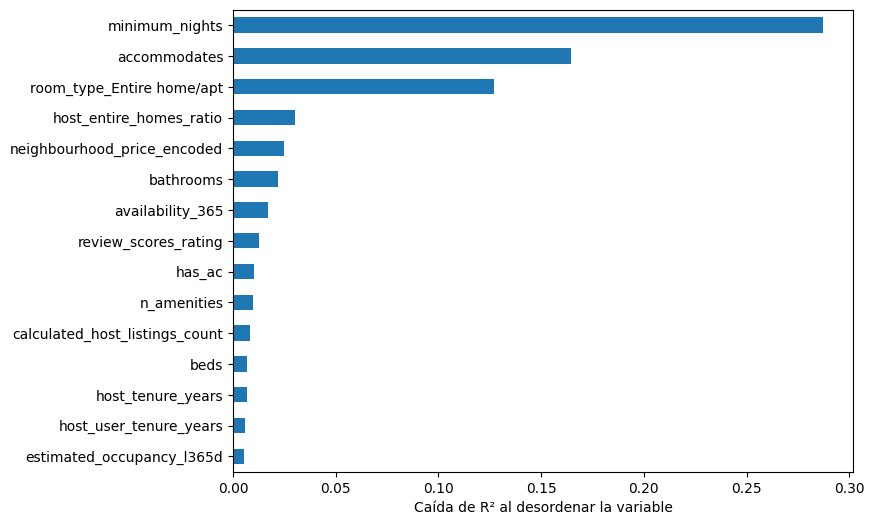

In [20]:
plt.figure(figsize=(8, 6))
importances.head(15).sort_values().plot(kind="barh")
plt.xlabel("Caída de R² al desordenar la variable")

### 10.2 Interpretación

**`minimum_nights` vuelve a dominar** (caída de R² de 0.287), igual que en Barcelona, seguido de `accommodates` (0.164) y `room_type_Entire home/apt` (0.127) — el mismo trío que en Barcelona, aunque aquí con una diferencia relativa menor entre el primero y el resto. Tiene la misma explicación que allí: un modelo de árboles puede aprovechar el patrón no lineal de "estancias largas más baratas por noche" mucho mejor que una correlación lineal simple.

Después del trío principal, `host_entire_homes_ratio` (0.030) y `neighbourhood_price_encoded` (0.025) aportan bastante menos, y `bathrooms`, `availability_365`, `review_scores_rating` todavía menos. Las variables nuevas de amenities (`has_ac`, `n_amenities`) aparecen en el top 15, con un peso modesto — a diferencia de Barcelona, donde ni siquiera entraban.

### 10.3 SHAP: cuánto y en qué dirección

Se calcula sobre el test, igual que la importancia por permutación.

In [21]:
explainer = shap.TreeExplainer(final_pipeline.named_steps["model"])
shap_values = explainer(X_test)

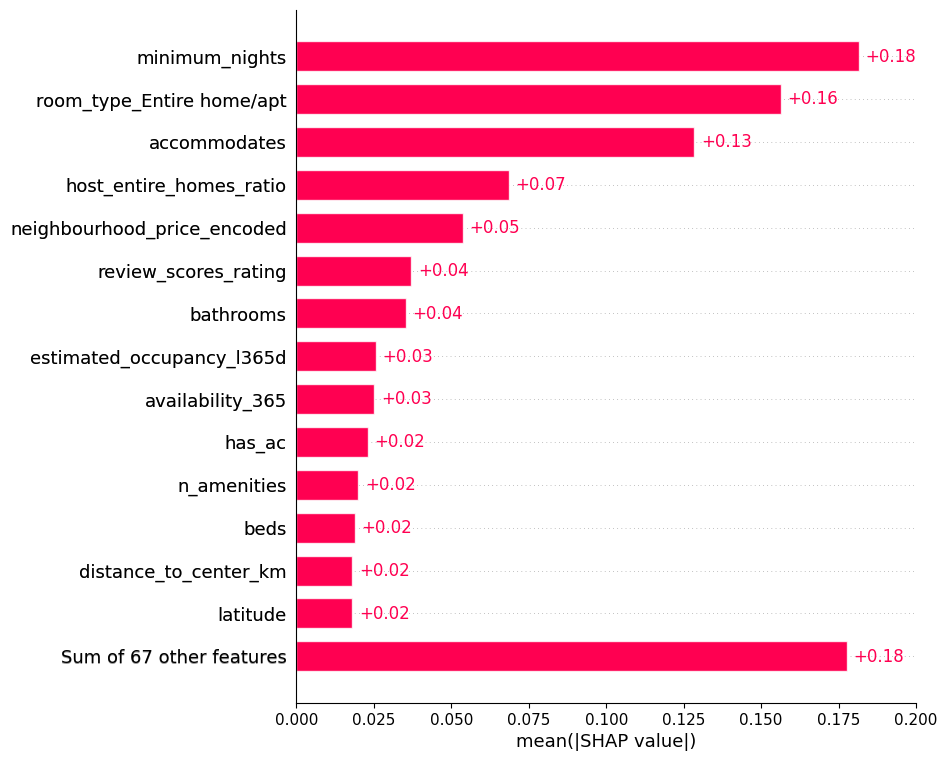

In [22]:
shap.plots.bar(shap_values, max_display=15)

Casi el mismo orden que la importancia por permutación, con un matiz: SHAP pone a `room_type_Entire home/apt` (0.156) por delante de `accommodates` (0.128), mientras que la permutación los ordenaba al revés. `minimum_nights` (0.182) sigue en cabeza con los dos métodos. Que ambos métodos coincidan en el mismo trío principal, aunque no en el orden exacto del 2º y 3er puesto, da confianza en el resultado sin forzar una precisión que los datos no sostienen.

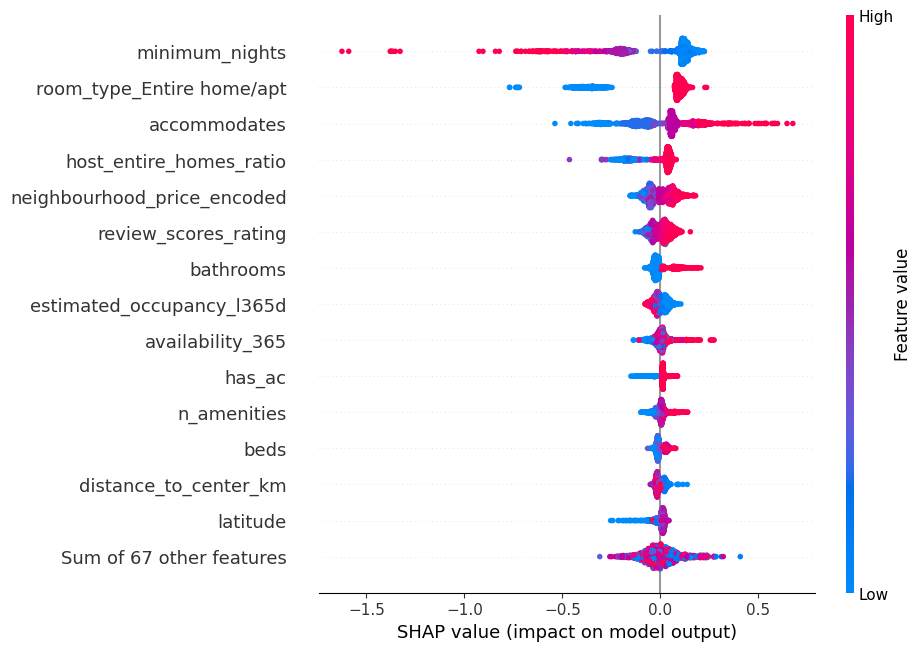

In [23]:
shap.plots.beeswarm(shap_values, max_display=15)

Aquí se ve la dirección: en `minimum_nights`, los valores altos empujan el precio hacia abajo con fuerza y los bajos lo empujan hacia arriba (correlación valor↔SHAP de -0.83) — el mismo patrón de "alquiler de larga estancia más barato por noche" que en Barcelona. En `accommodates` (0.94), `room_type_Entire home/apt` (0.98), `bathrooms` (0.79), `host_entire_homes_ratio` (0.95) y `neighbourhood_price_encoded` (0.90) es al revés: valores altos empujan hacia arriba, con una relación muy consistente en los cinco casos. `review_scores_rating` (0.65) también empuja hacia arriba cuando es alto, pero con un peso total mucho menor (coherente con su correlación casi nula con `price` ya vista en la EDA): cuando sí importa, importa en la dirección esperada, solo que rara vez decide el precio por sí sola.

### 10.4 Un ejemplo concreto

Se elige un anuncio de precio cercano a la mediana del test, y donde además el modelo acierta bastante.

Precio real: 166.00€, predicho: 171.96€


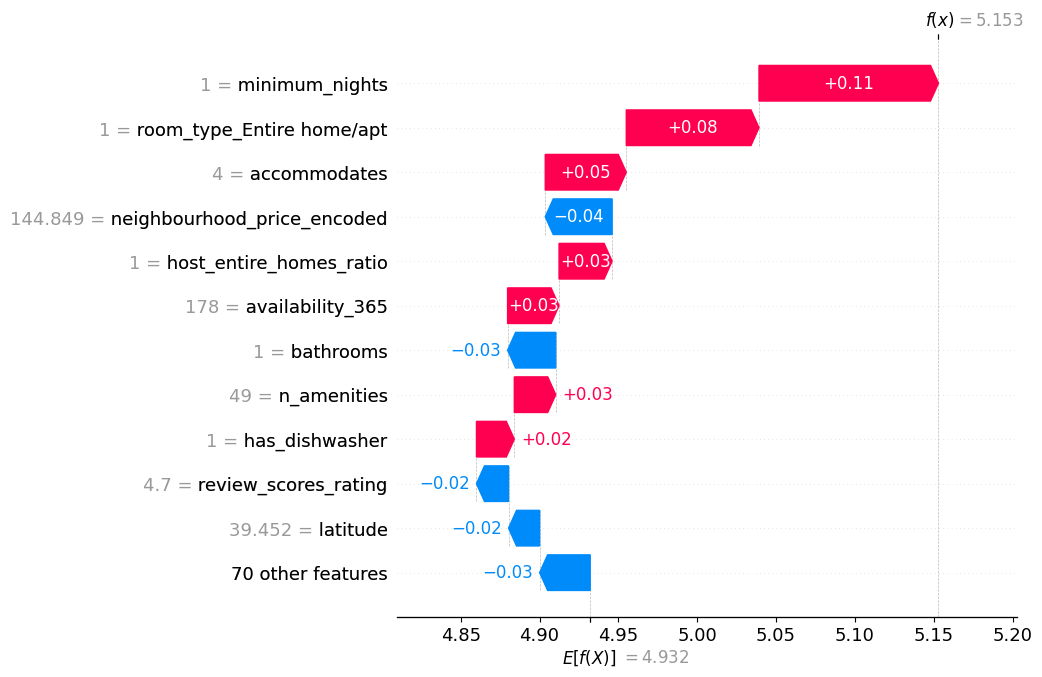

In [24]:
pred_test_all = np.expm1(final_pipeline.predict(X_test))
error_test = pred_test_all - y_test.values
median_price = y_test.median()

candidate_mask = (np.abs(y_test.values - median_price) < 20) & (np.abs(error_test) < 10)
example_pos = np.where(candidate_mask)[0][0]

print(f"Precio real: {y_test.iloc[example_pos]:.2f}€, predicho: {pred_test_all[example_pos]:.2f}€")
shap.plots.waterfall(shap_values[example_pos], max_display=12)

El valor base (`E[f(X)]`) equivale a unos 138€. Para este anuncio en concreto (piso entero para 4 personas, 1 baño, `minimum_nights=1`, disponible 178 días al año, en un barrio algo por debajo de la media de precio): `minimum_nights=1` (sin exigir estancia larga) empuja el precio hacia arriba con fuerza, `room_type_Entire home/apt=1` y `accommodates=4` también lo empujan hacia arriba, mientras que `neighbourhood_price_encoded` (por debajo de la media) y `bathrooms=1` lo empujan ligeramente hacia abajo, hasta llegar a la predicción final de 172€ (el precio real era 166€, un acierto razonable). El mismo tipo de desglose que en Barcelona: "tu precio sube por ser piso entero, capacidad para 4 y no exigir estancia mínima larga, pero baja un poco por estar en un barrio algo más económico".

## 11. Guardar el modelo

Guardar el modelo final entrenado (con `joblib`) en `models/valencia/`, para que `05_model_evaluation.ipynb` lo cargue directamente.

### 11.1 El modelo

In [25]:
import joblib

joblib.dump(final_pipeline, f"{PROJECT_DIR}/models/valencia/price_model.pkl")

['/Users/yagocoll/Documents/Master/Airbnb/models/valencia/price_model.pkl']

### 11.2 Metadatos

Se guarda todo lo que `05_model_evaluation.ipynb` necesitará saber sin releer este notebook entero.

In [26]:
import json
from datetime import date

metadata = {
    "model": "HistGradientBoostingRegressor",
    "date": str(date.today()),
    "target": target_col,
    "id_cols": id_cols,
    "leakage_cols_excluded": leakage_cols,
    "feature_cols": feature_cols,
    "best_params": {k.replace("model__", ""): v for k, v in hgb_search.best_params_.items()},
    "test_metrics": evaluate(y_test, pred_final, "Hist Gradient Boosting (final)"),
    "baseline_metrics": {"model": "Regresión lineal", "RMSE": 114.70, "MAE": 45.55, "R2": 0.32, "MAPE": 29.10},
}


metadata["test_metrics"]["R2_log"] = float(r2_score(y_test_log, final_pipeline.predict(X_test)))
with open(f"{PROJECT_DIR}/models/valencia/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

metadata

{'model': 'HistGradientBoostingRegressor',
 'date': '2026-09-09',
 'target': 'price',
 'id_cols': ['id', 'host_id', 'host_profile_id'],
 'leakage_cols_excluded': ['price_log',
  'price_per_accommodate',
  'price_per_min_night'],
 'feature_cols': ['host_is_superhost',
  'host_has_profile_pic',
  'host_identity_verified',
  'latitude',
  'longitude',
  'accommodates',
  'bathrooms',
  'bedrooms',
  'beds',
  'minimum_nights',
  'maximum_nights',
  'availability_365',
  'number_of_reviews',
  'number_of_reviews_ltm',
  'estimated_occupancy_l365d',
  'review_scores_rating',
  'calculated_host_listings_count',
  'reviews_per_month',
  'has_license',
  'number_of_reviews_log',
  'number_of_reviews_ltm_log',
  'reviews_per_month_log',
  'bedrooms_log',
  'beds_log',
  'bathrooms_log',
  'calculated_host_listings_count_log',
  'room_type_Entire home/apt',
  'room_type_Hotel room',
  'room_type_Private room',
  'room_type_Shared room',
  'district_Algiros',
  'district_Benicalap',
  'district_B

`R2_log` (0.76) es el R² calculado sobre `log1p(price)`, la escala en la que el modelo realmente entrena — bastante más alto que el R² en euros (0.37), precisamente porque en euros pesan mucho los precios extremos que se vieron en la sección 8.2. Se guarda como métrica adicional para que la app pueda mostrar una cifra de "cuánto explica el modelo" comparable entre ciudades.

## 12. Conclusiones

Resumen de qué modelo ganó, cuánto mejora sobre el baseline, y qué variables resultaron más importantes.

### El proceso, resumido

1. Se probaron 4 tipos de modelo con hiperparámetros por defecto. A diferencia de Barcelona, los cuatro quedaron muy apretados (R² 0.25-0.29), con Hist Gradient Boosting ligeramente por delante.
2. Se afinaron los tres modelos de árboles. El resultado quedó en un empate técnico 2-2 entre Hist Gradient Boosting (mejor RMSE/R²) y Extra Trees (mejor MAE/MAPE); se optó por Hist Gradient Boosting por su ventaja en las métricas más sensibles a la cola larga de `price`, y por consistencia metodológica con Barcelona/Madrid.
3. El modelo final se evaluó en test una única vez.

### Resultado final

| Modelo | RMSE | MAE | R² | MAPE |
|---|---|---|---|---|
| Regresión lineal (baseline) | 114.70€ | 45.55€ | 0.32 | 29.10% |
| **Hist Gradient Boosting (final)** | **110.43€** | **39.65€** | **0.37** | **24.10%** |

Mejora real sobre el baseline en las cuatro métricas, aunque más modesta que en Barcelona/Madrid. Comparado también contra train: un caso atípico donde el R²/RMSE salen mejor en test que en train (sección 8.2), explicado por cómo se repartió la cola larga de `price` en el split aleatorio, no por un problema del modelo.

### Qué explica el precio, según el modelo

Permutation importance y SHAP coinciden en el trío principal: **`minimum_nights` domina**, seguido de `accommodates` y `room_type_Entire home/apt` (el orden exacto entre estos dos últimos varía ligeramente según el método). Igual que en Barcelona, es un giro respecto a la EDA, donde el tamaño parecía lo más determinante: el patrón no lineal de `minimum_nights` (estancias largas más baratas por noche) es más fuerte de lo que sugería su correlación de Pearson. A diferencia de Barcelona, aquí sí entran variables de amenities (`has_ac`, `n_amenities`) en el top 15, con peso modesto.

### Qué queda pendiente

- El análisis de errores más detallado se deja para `05_model_evaluation.ipynb`, que parte de `models/valencia/price_model.pkl` y `models/valencia/model_metadata.json` ya guardados aquí.
- Dado el hallazgo de la sección 8.2 (varianza alta del split frente a la cola larga de `price`), sería razonable que `05_model_evaluation.ipynb` revise el error específicamente en los anuncios de precio muy alto, en vez de fiarse solo del R²/RMSE agregado de un único split.